In [ ]:
Perceptron 

#  Single Layer Perceptron #  

Device: cpu
TRAIN_PATH: /kaggle/input/competitions/digit-recognizer/train.csv
TEST_PATH : /kaggle/input/competitions/digit-recognizer/test.csv
Train shape: (42000, 785)
Test shape : (28000, 784)
Perceptron(
  (fc): Linear(in_features=784, out_features=10, bias=True)
)


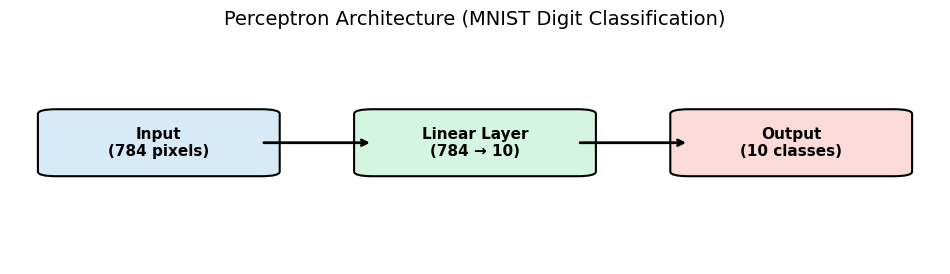

Trainable parameters: 7850

Perceptron Architecture

Input Layer: 784 features (28x28 image flattened)
↓
Linear Layer (784 → 10)
↓
Softmax via CrossEntropyLoss
↓
Output: Digit class (0-9)

Epoch 1/8 | Train Loss 0.7906 Acc 0.8287 | Val Loss 0.4636 Acc 0.8800
Epoch 2/8 | Train Loss 0.4045 Acc 0.8940 | Val Loss 0.3719 Acc 0.8960
Epoch 3/8 | Train Loss 0.3450 Acc 0.9068 | Val Loss 0.3369 Acc 0.9048
Epoch 4/8 | Train Loss 0.3173 Acc 0.9130 | Val Loss 0.3179 Acc 0.9090
Epoch 5/8 | Train Loss 0.3016 Acc 0.9166 | Val Loss 0.3044 Acc 0.9131
Epoch 6/8 | Train Loss 0.2898 Acc 0.9200 | Val Loss 0.2975 Acc 0.9145
Epoch 7/8 | Train Loss 0.2810 Acc 0.9220 | Val Loss 0.2908 Acc 0.9155
Epoch 8/8 | Train Loss 0.2738 Acc 0.9243 | Val Loss 0.2868 Acc 0.9176

Final Validation Accuracy: 0.9176190476190477
Final Validation F1 Score: 0.9167208511085339
Training Time: 16.85255002975464


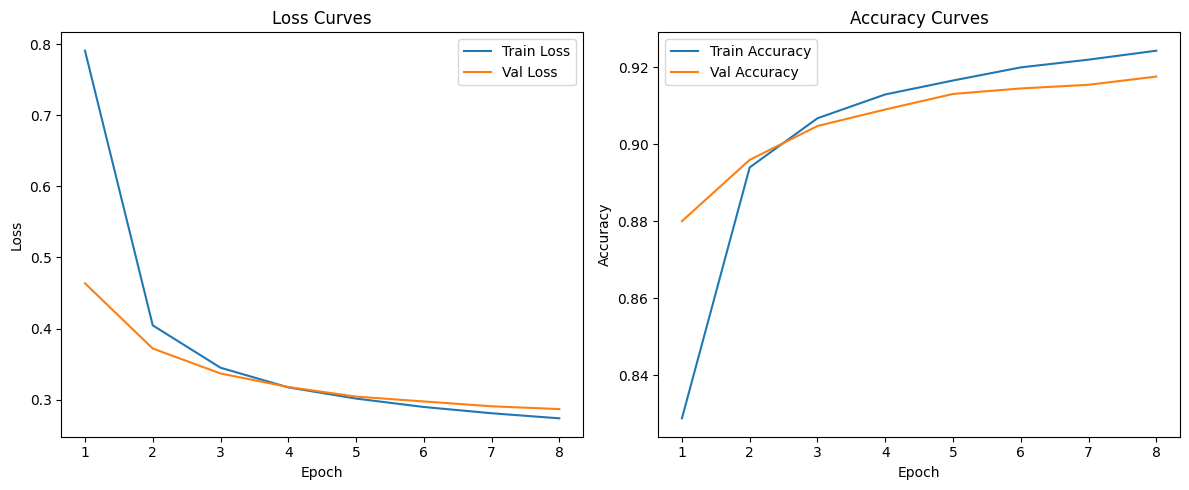

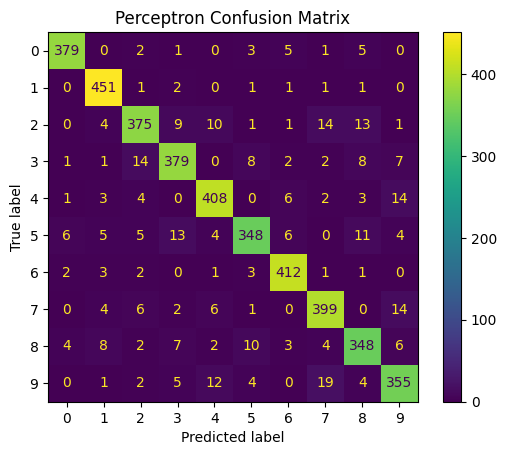

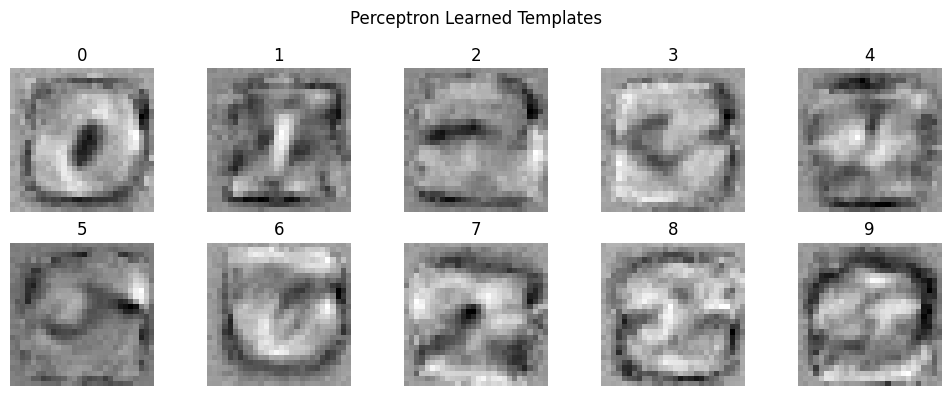

[Full Train] Epoch 1/8 Loss 0.7677
[Full Train] Epoch 2/8 Loss 0.3922
[Full Train] Epoch 3/8 Loss 0.3369
[Full Train] Epoch 4/8 Loss 0.3117
[Full Train] Epoch 5/8 Loss 0.2965
[Full Train] Epoch 6/8 Loss 0.2857
[Full Train] Epoch 7/8 Loss 0.2766
[Full Train] Epoch 8/8 Loss 0.2712
Saved submission_perceptron.csv
   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      7
4        5      3

Perceptron Results Summary
{'Model': 'Perceptron', 'Val Accuracy': np.float64(0.9176190476190477), 'Val F1': 0.9167208511085339, 'Train Time (s)': 16.85255002975464, 'Params': 7850, 'Kaggle Score': 0.0}


In [2]:
# =========================
# Perceptron Notebook (Digit Recognizer)
# =========================

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------------
# Find dataset automatically
# -----------------------------
def find_digit_recognizer_paths():
    base = "/kaggle/input"
    for root, _, files in os.walk(base):
        if "train.csv" in files and "test.csv" in files:
            return os.path.join(root, "train.csv"), os.path.join(root, "test.csv")
    raise FileNotFoundError("Digit Recognizer dataset not found")

TRAIN_PATH, TEST_PATH = find_digit_recognizer_paths()

print("TRAIN_PATH:", TRAIN_PATH)
print("TEST_PATH :", TEST_PATH)

# -----------------------------
# Load dataset
# -----------------------------
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

y_all = train_df["label"].values.astype(np.int64)
X_all = train_df.drop(columns=["label"]).values.astype(np.float32) / 255.0
X_test = test_df.values.astype(np.float32) / 255.0

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

# -----------------------------
# Dataset class
# -----------------------------
class MNISTDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        if self.y is None:
            return x
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y

# -----------------------------
# Train / Validation split
# -----------------------------
full_ds = MNISTDataset(X_all, y_all)

val_size = int(0.1 * len(full_ds))
train_size = len(full_ds) - val_size

generator = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(full_ds, [train_size, val_size], generator=generator)

BATCH_SIZE = 128

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# -----------------------------
# Perceptron model
# -----------------------------
class Perceptron(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(784, 10)

    def forward(self, x):
        return self.fc(x)

model = Perceptron().to(device)
print(model)

# -----------------------------
# Perceptron Architecture Diagram
# -----------------------------
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(12, 3))

def draw_box(text, x, color):
    box = FancyBboxPatch(
        (x, 0.4), 0.22, 0.25,
        boxstyle="round,pad=0.02",
        linewidth=1.5,
        edgecolor="black",
        facecolor=color
    )
    ax.add_patch(box)
    ax.text(
        x + 0.11, 0.525, text,
        ha="center", va="center",
        fontsize=11, weight="bold"
    )

draw_box("Input\n(784 pixels)", 0.05, "#D6EAF8")
draw_box("Linear Layer\n(784 → 10)", 0.39, "#D5F5E3")
draw_box("Output\n(10 classes)", 0.73, "#FADBD8")

ax.annotate("", xy=(0.39, 0.525), xytext=(0.27, 0.525),
            arrowprops=dict(arrowstyle="->", linewidth=2))
ax.annotate("", xy=(0.73, 0.525), xytext=(0.61, 0.525),
            arrowprops=dict(arrowstyle="->", linewidth=2))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Perceptron Architecture (MNIST Digit Classification)", fontsize=14)
ax.axis("off")
plt.show()

# -----------------------------
# Parameter count
# -----------------------------
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters:", count_params(model))

print("""
Perceptron Architecture

Input Layer: 784 features (28x28 image flattened)
↓
Linear Layer (784 → 10)
↓
Softmax via CrossEntropyLoss
↓
Output: Digit class (0-9)
""")

# -----------------------------
# Training Setup
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 8

# -----------------------------
# Evaluation function
# -----------------------------
def eval_acc_f1(model, loader):
    model.eval()

    all_preds = []
    all_true = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            logits = model(x)
            preds = torch.argmax(logits, dim=1)

            all_preds.append(preds.cpu().numpy())
            all_true.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_true = np.concatenate(all_true)

    acc = (all_preds == all_true).mean()
    f1 = f1_score(all_true, all_preds, average="macro")

    return acc, f1, all_true, all_preds

# -----------------------------
# Training Loop
# -----------------------------
train_losses = []
val_losses = []

train_accs = []
val_accs = []

start = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # Validation
    model.eval()

    val_loss = 0.0
    vcorrect = 0
    vtotal = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            vcorrect += (preds == y).sum().item()
            vtotal += y.size(0)

    val_loss /= len(val_loader)
    val_acc = vcorrect / vtotal

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} Acc {val_acc:.4f}"
    )

train_time = time.time() - start

# -----------------------------
# Final Evaluation
# -----------------------------
final_acc, final_f1, y_true, y_pred = eval_acc_f1(model, val_loader)

print("\nFinal Validation Accuracy:", final_acc)
print("Final Validation F1 Score:", final_f1)
print("Training Time:", train_time)

# -----------------------------
# Training Curves
# -----------------------------
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(values_format="d")
plt.title("Perceptron Confusion Matrix")
plt.show()

# -----------------------------
# Visualize learned weights
# -----------------------------
W = model.fc.weight.detach().cpu().numpy().reshape(10, 28, 28)

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(W[i], cmap="gray")
    plt.title(str(i))
    plt.axis("off")

plt.suptitle("Perceptron Learned Templates")
plt.tight_layout()
plt.show()

# -----------------------------
# Train on full dataset
# -----------------------------
full_loader = DataLoader(MNISTDataset(X_all, y_all), batch_size=BATCH_SIZE, shuffle=True)

# Reinitialize model for full training
model = Perceptron().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0

    for x, y in full_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        running += loss.item()

    print(f"[Full Train] Epoch {epoch}/{EPOCHS} Loss {running / len(full_loader):.4f}")

# -----------------------------
# Kaggle Submission
# -----------------------------
test_loader = DataLoader(MNISTDataset(X_test), batch_size=BATCH_SIZE, shuffle=False)

model.eval()
preds_all = []

with torch.no_grad():
    for x in test_loader:
        x = x.to(device)
        preds = torch.argmax(model(x), dim=1)
        preds_all.append(preds.cpu().numpy())

preds_all = np.concatenate(preds_all)

submission = pd.DataFrame({
    "ImageId": np.arange(1, len(preds_all) + 1),
    "Label": preds_all
})

submission.to_csv("submission_perceptron.csv", index=False)

print("Saved submission_perceptron.csv")
print(submission.head())

# -----------------------------
# Save results for comparison
# -----------------------------
perceptron_results = {
    "Model": "Perceptron",
    "Val Accuracy": final_acc,
    "Val F1": final_f1,
    "Train Time (s)": train_time,
    "Params": count_params(model),
    "Kaggle Score": 0.0
}

print("\nPerceptron Results Summary")
print(perceptron_results)

# Multi Layer Perceptron # 

Device: cpu


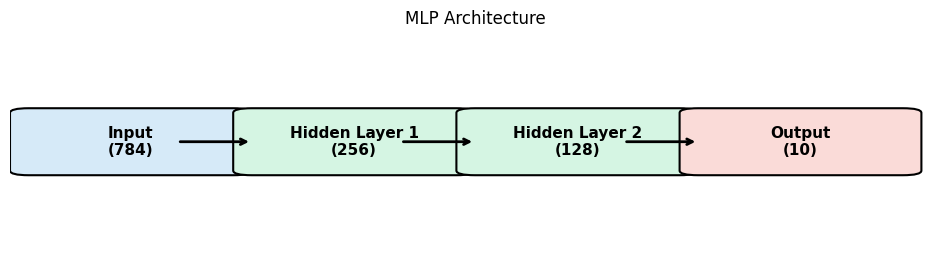

MLP(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)
Trainable parameters: 235146
Epoch 1/8 | Train Loss 0.4280 Acc 0.8826 | Val Loss 0.2133 Acc 0.9388
Epoch 2/8 | Train Loss 0.1696 Acc 0.9506 | Val Loss 0.1528 Acc 0.9540
Epoch 3/8 | Train Loss 0.1138 Acc 0.9658 | Val Loss 0.1431 Acc 0.9612
Epoch 4/8 | Train Loss 0.0815 Acc 0.9758 | Val Loss 0.1132 Acc 0.9660
Epoch 5/8 | Train Loss 0.0623 Acc 0.9812 | Val Loss 0.1134 Acc 0.9660
Epoch 6/8 | Train Loss 0.0483 Acc 0.9855 | Val Loss 0.1205 Acc 0.9662
Epoch 7/8 | Train Loss 0.0366 Acc 0.9886 | Val Loss 0.1121 Acc 0.9688
Epoch 8/8 | Train Loss 0.0281 Acc 0.9911 | Val Loss 0.1122 Acc 0.9714
Final Val Accuracy: 0.9714285714285714
Final Val F1: 0.9712614719778621


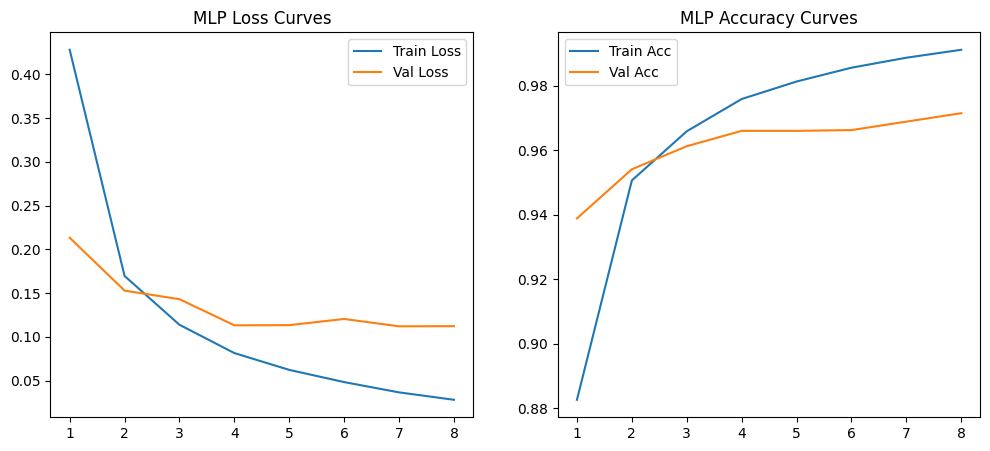

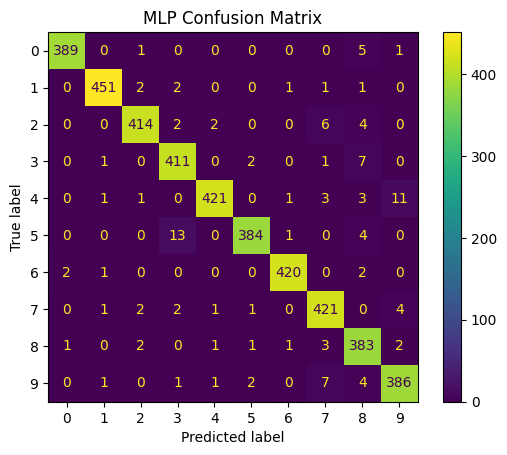

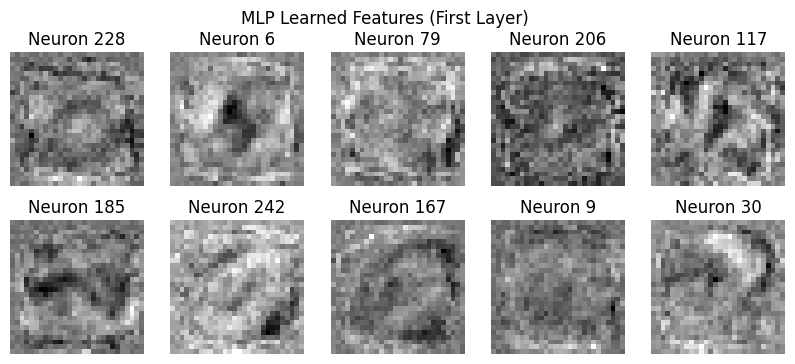

[Full Train] Epoch 1/8 Loss 0.0367
[Full Train] Epoch 2/8 Loss 0.0254
[Full Train] Epoch 3/8 Loss 0.0188
[Full Train] Epoch 4/8 Loss 0.0168
[Full Train] Epoch 5/8 Loss 0.0158
[Full Train] Epoch 6/8 Loss 0.0091
[Full Train] Epoch 7/8 Loss 0.0115
[Full Train] Epoch 8/8 Loss 0.0091
Saved submission_mlp.csv
{'Model': 'MLP', 'Val Accuracy': np.float64(0.9714285714285714), 'Val F1': 0.9712614719778621, 'Train Time (s)': 22.628910541534424, 'Params': 235146, 'Kaggle Score': 0.0}


In [25]:
# =========================
# MLP Notebook (Digit Recognizer)
# =========================

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------------
# Find dataset automatically
# -----------------------------
def find_digit_recognizer_paths():
    base="/kaggle/input"
    for root,_,files in os.walk(base):
        if "train.csv" in files and "test.csv" in files:
            return os.path.join(root,"train.csv"),os.path.join(root,"test.csv")
    raise FileNotFoundError("Digit Recognizer dataset not found")

TRAIN_PATH,TEST_PATH=find_digit_recognizer_paths()

train_df=pd.read_csv(TRAIN_PATH)
test_df=pd.read_csv(TEST_PATH)

y_all=train_df["label"].values.astype(np.int64)
X_all=train_df.drop(columns=["label"]).values.astype(np.float32)/255.0
X_test=test_df.values.astype(np.float32)/255.0

# -----------------------------
# Dataset
# -----------------------------
class MNISTDataset(Dataset):
    def __init__(self,X,y=None):
        self.X=X
        self.y=y

    def __len__(self):
        return len(self.X)

    def __getitem__(self,idx):

        x=torch.tensor(self.X[idx],dtype=torch.float32)

        if self.y is None:
            return x

        y=torch.tensor(self.y[idx],dtype=torch.long)

        return x,y


full_ds=MNISTDataset(X_all,y_all)

val_size=int(0.1*len(full_ds))
train_size=len(full_ds)-val_size

train_ds,val_ds=random_split(full_ds,[train_size,val_size])

BATCH_SIZE=128

train_loader=DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True)
val_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False)

# -----------------------------
# MLP Architecture Diagram
# -----------------------------
from matplotlib.patches import FancyBboxPatch

fig,ax=plt.subplots(figsize=(12,3))

def draw_box(text,x,color):

    box=FancyBboxPatch((x,0.4),0.22,0.25,
                       boxstyle="round,pad=0.02",
                       linewidth=1.5,
                       edgecolor="black",
                       facecolor=color)

    ax.add_patch(box)

    ax.text(x+0.11,0.525,text,
            ha="center",
            va="center",
            fontsize=11,
            weight="bold")

draw_box("Input\n(784)",0.02,"#D6EAF8")
draw_box("Hidden Layer 1\n(256)",0.26,"#D5F5E3")
draw_box("Hidden Layer 2\n(128)",0.50,"#D5F5E3")
draw_box("Output\n(10)",0.74,"#FADBD8")

ax.annotate("",xy=(0.26,0.525),xytext=(0.18,0.525),arrowprops=dict(arrowstyle="->",linewidth=2))
ax.annotate("",xy=(0.50,0.525),xytext=(0.42,0.525),arrowprops=dict(arrowstyle="->",linewidth=2))
ax.annotate("",xy=(0.74,0.525),xytext=(0.66,0.525),arrowprops=dict(arrowstyle="->",linewidth=2))

ax.axis("off")
ax.set_title("MLP Architecture")

plt.show()

# -----------------------------
# Model
# -----------------------------
class MLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1=nn.Linear(784,256)
        self.fc2=nn.Linear(256,128)
        self.fc3=nn.Linear(128,10)

        self.relu=nn.ReLU()

    def forward(self,x):

        x=self.relu(self.fc1(x))
        x=self.relu(self.fc2(x))
        x=self.fc3(x)

        return x


model=MLP().to(device)

print(model)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("Trainable parameters:",count_params(model))

# -----------------------------
# Training Setup
# -----------------------------
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=1e-3)

EPOCHS=8

def eval_acc_f1(model,loader):

    model.eval()

    all_preds=[]
    all_true=[]

    with torch.no_grad():

        for x,y in loader:

            x,y=x.to(device),y.to(device)

            logits=model(x)

            preds=torch.argmax(logits,dim=1)

            all_preds.append(preds.cpu().numpy())
            all_true.append(y.cpu().numpy())

    all_preds=np.concatenate(all_preds)
    all_true=np.concatenate(all_true)

    acc=(all_preds==all_true).mean()
    f1=f1_score(all_true,all_preds,average="macro")

    return acc,f1,all_true,all_preds


# -----------------------------
# Training Loop
# -----------------------------
train_losses=[]
val_losses=[]
train_accs=[]
val_accs=[]

start=time.time()

for epoch in range(1,EPOCHS+1):

    model.train()

    running_loss=0
    correct=0
    total=0

    for x,y in train_loader:

        x,y=x.to(device),y.to(device)

        optimizer.zero_grad()

        logits=model(x)

        loss=criterion(logits,y)

        loss.backward()

        optimizer.step()

        running_loss+=loss.item()

        preds=torch.argmax(logits,dim=1)

        correct+=(preds==y).sum().item()
        total+=y.size(0)

    tr_loss=running_loss/len(train_loader)
    tr_acc=correct/total

    model.eval()

    vloss=0
    vcorrect=0
    vtotal=0

    with torch.no_grad():

        for x,y in val_loader:

            x,y=x.to(device),y.to(device)

            logits=model(x)

            loss=criterion(logits,y)

            vloss+=loss.item()

            preds=torch.argmax(logits,dim=1)

            vcorrect+=(preds==y).sum().item()
            vtotal+=y.size(0)

    va_loss=vloss/len(val_loader)
    va_acc=vcorrect/vtotal

    train_losses.append(tr_loss)
    val_losses.append(va_loss)

    train_accs.append(tr_acc)
    val_accs.append(va_acc)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")

train_time=time.time()-start

final_acc,final_f1,y_true,y_pred=eval_acc_f1(model,val_loader)

print("Final Val Accuracy:",final_acc)
print("Final Val F1:",final_f1)

# -----------------------------
# Curves
# -----------------------------
epochs=range(1,EPOCHS+1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs,train_losses,label="Train Loss")
plt.plot(epochs,val_losses,label="Val Loss")
plt.legend()
plt.title("MLP Loss Curves")

plt.subplot(1,2,2)
plt.plot(epochs,train_accs,label="Train Acc")
plt.plot(epochs,val_accs,label="Val Acc")
plt.legend()
plt.title("MLP Accuracy Curves")

plt.show()

# -----------------------------
# Confusion Matrix
# -----------------------------
cm=confusion_matrix(y_true,y_pred)

disp=ConfusionMatrixDisplay(cm)
disp.plot(values_format="d")

plt.title("MLP Confusion Matrix")
plt.show()


# -----------------------------
# Learned Features (MLP)
# -----------------------------
W1 = model.fc1.weight.detach().cpu().numpy()  # shape (256,784)

# pick 10 random neurons
idx = np.random.choice(W1.shape[0],10,replace=False)

plt.figure(figsize=(10,4))

for i,k in enumerate(idx):
    
    plt.subplot(2,5,i+1)
    plt.imshow(W1[k].reshape(28,28), cmap="gray")
    plt.title(f"Neuron {k}")
    plt.axis("off")

plt.suptitle("MLP Learned Features (First Layer)")
plt.show()

# -----------------------------
# Train on full dataset (MLP)
# -----------------------------
full_loader = DataLoader(MNISTDataset(X_all, y_all), batch_size=BATCH_SIZE, shuffle=True)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

model.train()

for epoch in range(1, EPOCHS + 1):

    running = 0

    for x, y in full_loader:

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        loss = criterion(model(x), y)

        loss.backward()

        optimizer.step()

        running += loss.item()

    print(f"[Full Train] Epoch {epoch}/{EPOCHS} Loss {running/len(full_loader):.4f}")

# -----------------------------
# Submission
# -----------------------------
test_loader=DataLoader(MNISTDataset(X_test),batch_size=BATCH_SIZE)

model.eval()

preds_all=[]

with torch.no_grad():

    for x in test_loader:

        x=x.to(device)

        preds=torch.argmax(model(x),dim=1)

        preds_all.append(preds.cpu().numpy())

preds_all=np.concatenate(preds_all)

submission=pd.DataFrame({
"ImageId":np.arange(1,len(preds_all)+1),
"Label":preds_all
})

submission.to_csv("submission_mlp.csv",index=False)

print("Saved submission_mlp.csv")

# -----------------------------
# Save Results
# -----------------------------
mlp_results={
"Model":"MLP",
"Val Accuracy":final_acc,
"Val F1":final_f1,
"Train Time (s)":train_time,
"Params":count_params(model),
"Kaggle Score": 0.0
}

print(mlp_results)

 # Convolutional Neural Network # 

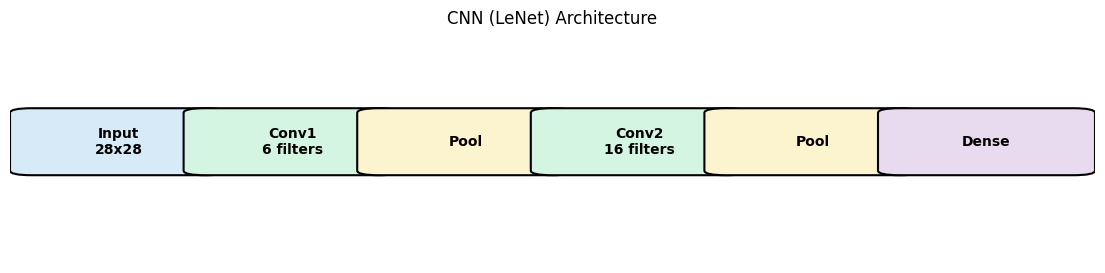

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
Trainable parameters: 44426
Epoch 8/8 | Train Loss 0.0452 Acc 0.9852 | Val Loss 0.0664 Acc 0.9824
Accuracy: 0.9823809523809524


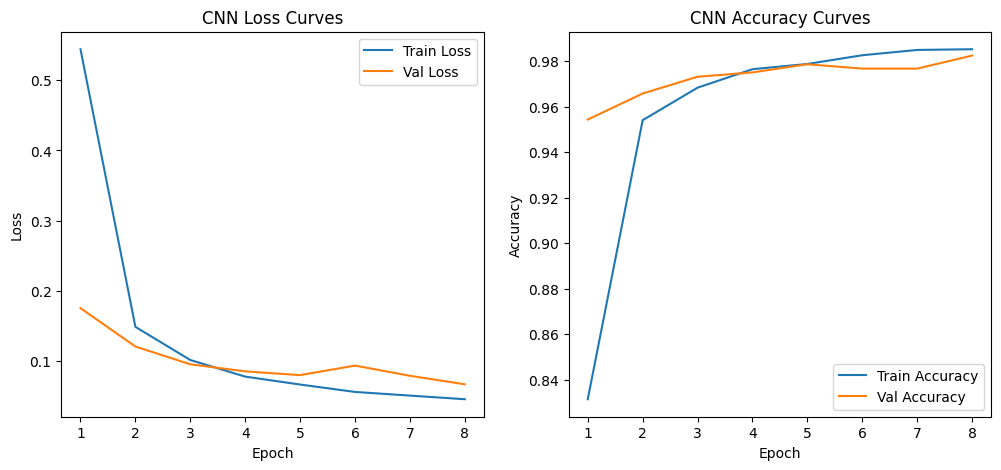

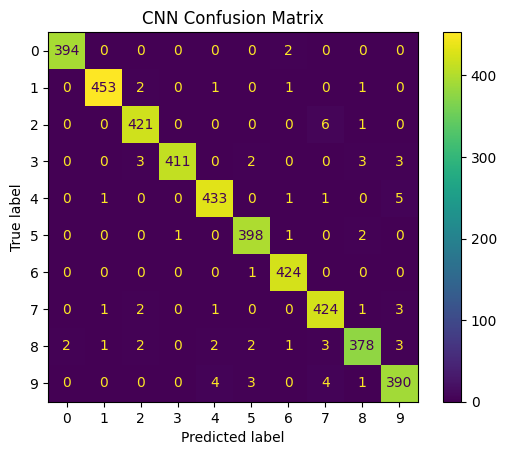

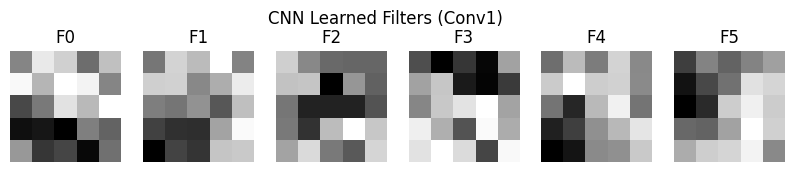

[Full Train] Epoch 1/8 Loss 0.0453
[Full Train] Epoch 2/8 Loss 0.0390
[Full Train] Epoch 3/8 Loss 0.0329
[Full Train] Epoch 4/8 Loss 0.0309
[Full Train] Epoch 5/8 Loss 0.0270
[Full Train] Epoch 6/8 Loss 0.0229
[Full Train] Epoch 7/8 Loss 0.0208
[Full Train] Epoch 8/8 Loss 0.0196
Saved submission_cnn.csv
{'Model': 'CNN (LeNet)', 'Val Accuracy': np.float64(0.9823809523809524), 'Val F1': 0.9822425378526667, 'Train Time (s)': 34.96070718765259, 'Params': 44426, 'Kaggle Score': 0.0}


In [2]:
# =========================
# CNN (LeNet) Notebook
# =========================

import os,time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader,random_split

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,f1_score

SEED=42
torch.manual_seed(SEED)
np.random.seed(SEED)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Load dataset
# -----------------------------
def find_digit_recognizer_paths():
    base="/kaggle/input"
    for root,_,files in os.walk(base):
        if "train.csv" in files and "test.csv" in files:
            return os.path.join(root,"train.csv"),os.path.join(root,"test.csv")

TRAIN_PATH,TEST_PATH=find_digit_recognizer_paths()

train_df=pd.read_csv(TRAIN_PATH)
test_df=pd.read_csv(TEST_PATH)

y_all=train_df["label"].values.astype(np.int64)
X_all=train_df.drop(columns=["label"]).values.astype(np.float32)/255.0
X_test=test_df.values.astype(np.float32)/255.0

# -----------------------------
# Dataset
# -----------------------------
class MNISTDatasetCNN(Dataset):

    def __init__(self,X,y=None):

        self.X=X
        self.y=y

    def __len__(self):
        return len(self.X)

    def __getitem__(self,idx):

        x=self.X[idx].reshape(1,28,28)

        x=torch.tensor(x,dtype=torch.float32)

        if self.y is None:
            return x

        y=torch.tensor(self.y[idx],dtype=torch.long)

        return x,y


full_ds=MNISTDatasetCNN(X_all,y_all)

val_size=int(0.1*len(full_ds))
train_size=len(full_ds)-val_size

train_ds,val_ds=random_split(full_ds,[train_size,val_size])

BATCH_SIZE=128

train_loader=DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True)
val_loader=DataLoader(val_ds,batch_size=BATCH_SIZE)

# -----------------------------
# CNN Architecture Diagram
# -----------------------------
from matplotlib.patches import FancyBboxPatch

fig,ax=plt.subplots(figsize=(14,3))

def draw_box(text,x,color):

    box=FancyBboxPatch((x,0.4),0.16,0.25,
                       boxstyle="round,pad=0.02",
                       linewidth=1.5,
                       edgecolor="black",
                       facecolor=color)

    ax.add_patch(box)

    ax.text(x+0.08,0.525,text,
            ha="center",
            va="center",
            fontsize=10,
            weight="bold")

draw_box("Input\n28x28",0.02,"#D6EAF8")
draw_box("Conv1\n6 filters",0.18,"#D5F5E3")
draw_box("Pool",0.34,"#FCF3CF")
draw_box("Conv2\n16 filters",0.50,"#D5F5E3")
draw_box("Pool",0.66,"#FCF3CF")
draw_box("Dense",0.82,"#E8DAEF")

ax.axis("off")
ax.set_title("CNN (LeNet) Architecture")

plt.show()

# -----------------------------
# Model
# -----------------------------
class LeNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1=nn.Conv2d(1,6,5)
        self.pool=nn.MaxPool2d(2,2)
        self.conv2=nn.Conv2d(6,16,5)

        self.fc1=nn.Linear(256,120)
        self.fc2=nn.Linear(120,84)
        self.fc3=nn.Linear(84,10)

    def forward(self,x):

        x=self.pool(torch.relu(self.conv1(x)))
        x=self.pool(torch.relu(self.conv2(x)))

        x=x.view(x.size(0),-1)

        x=torch.relu(self.fc1(x))
        x=torch.relu(self.fc2(x))

        return self.fc3(x)


model=LeNet().to(device)

print(model)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("Trainable parameters:",count_params(model))

criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=1e-3)

EPOCHS=8

# -----------------------------
# Training Loop
# -----------------------------
train_losses=[]
val_losses=[]
train_accs=[]
val_accs=[]

start=time.time()

for epoch in range(1,EPOCHS+1):

    model.train()

    running_loss=0
    correct=0
    total=0

    for x,y in train_loader:

        x,y=x.to(device),y.to(device)

        optimizer.zero_grad()

        logits=model(x)

        loss=criterion(logits,y)

        loss.backward()

        optimizer.step()

        running_loss+=loss.item()

        preds=torch.argmax(logits,dim=1)

        correct+=(preds==y).sum().item()
        total+=y.size(0)

    tr_loss=running_loss/len(train_loader)
    tr_acc=correct/total

    model.eval()

    vloss=0
    vcorrect=0
    vtotal=0

    with torch.no_grad():

        for x,y in val_loader:

            x,y=x.to(device),y.to(device)

            logits=model(x)

            loss=criterion(logits,y)

            vloss+=loss.item()

            preds=torch.argmax(logits,dim=1)

            vcorrect+=(preds==y).sum().item()
            vtotal+=y.size(0)

    va_loss=vloss/len(val_loader)
    va_acc=vcorrect/vtotal

    train_losses.append(tr_loss)
    val_losses.append(va_loss)

    train_accs.append(tr_acc)
    val_accs.append(va_acc)


print(f"Epoch {epoch}/{EPOCHS} | Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | Val Loss {va_loss:.4f} Acc {va_acc:.4f}")



train_time=time.time()-start

# -----------------------------
# Evaluation
# -----------------------------
all_preds=[]
all_true=[]

model.eval()

with torch.no_grad():

    for x,y in val_loader:

        x,y=x.to(device),y.to(device)

        preds=torch.argmax(model(x),dim=1)

        all_preds.append(preds.cpu().numpy())
        all_true.append(y.cpu().numpy())

all_preds=np.concatenate(all_preds)
all_true=np.concatenate(all_true)

final_acc=(all_preds==all_true).mean()
final_f1=f1_score(all_true,all_preds,average="macro")

print("Accuracy:",final_acc)


# -----------------------------
# Training Curves
# -----------------------------
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.legend()
plt.title("CNN Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Val Accuracy")
plt.legend()
plt.title("CNN Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()



# -----------------------------
# Confusion Matrix
# -----------------------------
cm=confusion_matrix(all_true,all_preds)

disp=ConfusionMatrixDisplay(cm)
disp.plot(values_format="d")

plt.title("CNN Confusion Matrix")
plt.show()

# -----------------------------
# CNN Learned Filters
# -----------------------------
filters = model.conv1.weight.detach().cpu().numpy()  # (6,1,5,5)

plt.figure(figsize=(10,2))

for i in range(filters.shape[0]):

    plt.subplot(1, filters.shape[0], i+1)
    plt.imshow(filters[i,0], cmap="gray")
    plt.title(f"F{i}")
    plt.axis("off")

plt.suptitle("CNN Learned Filters (Conv1)")
plt.show()

# -----------------------------
# Train on full dataset (CNN)
# -----------------------------
full_loader = DataLoader(MNISTDatasetCNN(X_all, y_all), batch_size=BATCH_SIZE, shuffle=True)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

model.train()

for epoch in range(1, EPOCHS + 1):

    running = 0

    for x, y in full_loader:

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        loss = criterion(model(x), y)

        loss.backward()

        optimizer.step()

        running += loss.item()

    print(f"[Full Train] Epoch {epoch}/{EPOCHS} Loss {running/len(full_loader):.4f}")

# -----------------------------
# Submission
# -----------------------------
test_loader=DataLoader(MNISTDatasetCNN(X_test),batch_size=BATCH_SIZE)

model.eval()

preds_all=[]

with torch.no_grad():

    for x in test_loader:

        x=x.to(device)

        preds=torch.argmax(model(x),dim=1)

        preds_all.append(preds.cpu().numpy())

preds_all=np.concatenate(preds_all)

submission=pd.DataFrame({
"ImageId":np.arange(1,len(preds_all)+1),
"Label":preds_all
})

submission.to_csv("submission_cnn.csv",index=False)

print("Saved submission_cnn.csv")

# -----------------------------
# Save Results
# -----------------------------
cnn_results={
"Model":"CNN (LeNet)",
"Val Accuracy":final_acc,
"Val F1":final_f1,
"Train Time (s)":train_time,
"Params":count_params(model),
"Kaggle Score": 0.0
}

print(cnn_results)

# Comparison Table # 

In [29]:
# =========================
# Model Comparison Table
# =========================

import pandas as pd

results = pd.DataFrame([
    perceptron_results,
    mlp_results,
    cnn_results
])

# nicer formatting
results = results[["Model","Val Accuracy","Val F1","Train Time (s)","Params","Kaggle Score"]]

results.style \
    .format({
        "Val Accuracy": "{:.4f}",
        "Val F1": "{:.4f}",
        "Train Time (s)": "{:.2f}",
        "Params": "{:,}",
        "Kaggle Score": "{:.5f}"
    }) \
    .background_gradient(subset=["Val Accuracy","Val F1"], cmap="Greens") \
    .set_caption("Comparison of Perceptron, MLP, and CNN Models on MNIST")

,Model,Val Accuracy,Val F1,Train Time (s),Params,Kaggle Score
0,Perceptron,0.9286,0.9278,12.67,"7,850",nan
1,MLP,0.9714,0.9713,22.63,"235,146",0.00000
2,CNN (LeNet),0.9819,0.9818,53.63,"44,426",0.00000


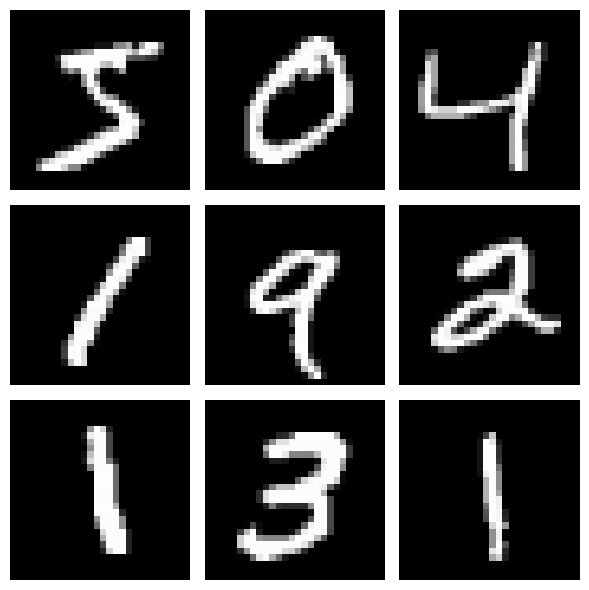

In [3]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(x_train, y_train), _ = mnist.load_data()

plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.savefig("mnist_samples.png", dpi=300)
plt.show()